In [1]:
from starccato_flow.training.trainer_flow_matching import FlowMatchingTrainer

MPS device found
630763148.816


/Users/tarineccleston/Desktop/starccato/starccato-flow/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Config

In [2]:
font_family = "sans-serif"
font_name = "Futura"

### Intrinsic + Sky Parameters

In [3]:
trainer = FlowMatchingTrainer(num_epochs=256, parameters=["beta1_IC_b", "omega_0(rad|s)","A(km)", "Ye_c_b", "ra", "dec", "d", "psi"])
trainer.load_model_instance(model_path="../outdir/flow_intrinsic_sky.pt")


=== Parameter Extraction Setup ===
Requested parameters: ['beta1_IC_b', 'omega_0(rad|s)', 'A(km)', 'Ye_c_b', 'ra', 'dec', 'd', 'psi']
Intrinsic params: ['beta1_IC_b', 'Ye_c_b']
Sky params: ['omega_0(rad|s)', 'A(km)', 'ra', 'dec', 'd', 'psi']
Extract indices (sequential from hThetaMulti): [0, 1, 2, 3, 4, 5, 6, 7]
Final flow parameter dimension: 8



✓ Loaded 1934076 supernova locations from /Users/tarineccleston/Desktop/starccato/starccato-flow/../data/supernovae/exploded_supernovae_t100_sf5.csv

sTheta Dataset - Parameter Bounds (4 parameters)
beta1_IC_b          : [    0.000000,     0.215477]
omega_0(rad|s)      : [    0.000000,    15.500000]
A(km)               : [  300.000000, 10000.000000]
Ye_c_b              : [    0.246499,     0.282820]


=== Data Split ===
Total signals: 1764
Training signals: 1588
Validation signals: 176
First 5 training indices: [  28  992 1389  878 1099]
First 5 validation indices: [  32  726  945 1158  389]

sTheta Dataset - Parameter Bounds (4 parameters)
beta1_IC_b          : [    0.000000,     0.215477]
omega_0(rad|s)      : [    0.000000,    15.500000]
A(km)               : [  300.000000, 10000.000000]
Ye_c_b              : [    0.246499,     0.282820]


sTheta Dataset - Parameter Bounds (4 parameters)
beta1_IC_b          : [    0.000000,     0.215477]
omega_0(rad|s)      : [    0.000000,    15.50

#### Performance Plots

✓ Created validation dataset with 2000 signals
  Processed 400/2000 signals...
  Processed 800/2000 signals...
  Processed 1200/2000 signals...
  Processed 1600/2000 signals...
  Processed 2000/2000 signals...
Generating calibration plots (p-p coverage + sky localization)...
68% Credible Interval: Median area = 55.18 deg²
90% Credible Interval: Median area = 89.80 deg²
95% Credible Interval: Median area = 97.67 deg²


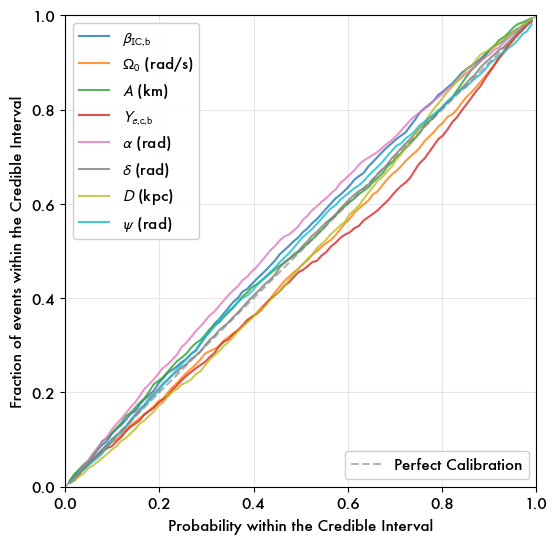

In [4]:
trainer.plot_model_performance(num_signals=2000, background="white", font_family=font_family, font_name=font_name, fname_pp="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_intrinsic_sky_pp_plot.pdf", fname_area_v_probability="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_intrinsic_sky_area_v_probability_plot.pdf", fname_distance_credible_intervals="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_intrinsic_sky_distance_credible_intervals_plot.pdf", fname_angular_error="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_intrinsic_sky_angular_error_vs_distance_plot.pdf", figsize=(14.5,14.5))

### Sky Parameters

In [5]:
trainer_sky = FlowMatchingTrainer(num_epochs=256, parameters=["ra", "dec", "d", "psi"], use_physics_aware_norm=True)
trainer_sky.load_model_instance(model_path="../outdir/flow_sky.pt")


=== Parameter Extraction Setup ===
Requested parameters: ['ra', 'dec', 'd', 'psi']
Intrinsic params: []
Sky params: ['ra', 'dec', 'd', 'psi']
Extract indices (sequential from hThetaMulti): [0, 1, 2, 3]
Final flow parameter dimension: 4

✓ Loaded 1934076 supernova locations from /Users/tarineccleston/Desktop/starccato/starccato-flow/../data/supernovae/exploded_supernovae_t100_sf5.csv

sTheta Dataset - Parameter Bounds (0 parameters)


=== Data Split ===
Total signals: 1764
Training signals: 1588
Validation signals: 176
First 5 training indices: [  28  992 1389  878 1099]
First 5 validation indices: [  32  726  945 1158  389]

sTheta Dataset - Parameter Bounds (0 parameters)


sTheta Dataset - Parameter Bounds (0 parameters)


Verifying data alignment:
Number of signals: 1588
Number of parameter sets: 1588
Parameter names: []
First few parameter values:
[]

Verifying data alignment:
Number of signals: 176
Number of parameter sets: 176
Parameter names: []
First few parameter values:
[]



#### Performance Plots

✓ Created validation dataset with 2000 signals
  Processed 400/2000 signals...
  Processed 800/2000 signals...
  Processed 1200/2000 signals...
  Processed 1600/2000 signals...
  Processed 2000/2000 signals...
Generating calibration plots (p-p coverage + sky localization)...
68% Credible Interval: Median area = 43.01 deg²
90% Credible Interval: Median area = 77.63 deg²
95% Credible Interval: Median area = 85.50 deg²


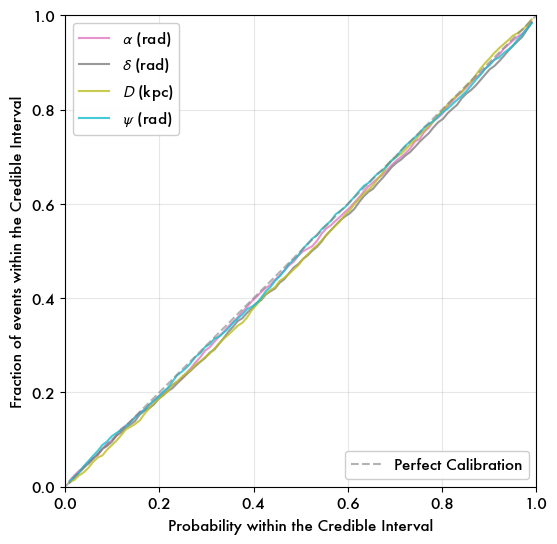

In [6]:
trainer_sky.plot_model_performance(num_signals=2000, background="white", font_family=font_family, font_name=font_name, fname_pp="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_sky_pp_plot.pdf", fname_area_v_probability="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_sky_area_v_probability_plot.pdf", fname_distance_credible_intervals="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_sky_distance_credible_intervals_plot.pdf", fname_angular_error="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_sky_angular_error_vs_distance_plot.pdf", figsize=(14.5,14.5))

### Add, Commit, Push

In [7]:
import subprocess

# Add all files
subprocess.run(["git", "pull"], cwd="../../2025-Statistics-Masters-Thesis")
subprocess.run(["git", "add", "."], cwd="../../2025-Statistics-Masters-Thesis")
# Commit
subprocess.run(["git", "commit", "-m", "Update Plots"], cwd="../../2025-Statistics-Masters-Thesis")
# Push
subprocess.run(["git", "push"], cwd="../../2025-Statistics-Masters-Thesis")

From github.com:the-tarin/2025-Statistics-Masters-Thesis
   3dfb6e2..8d992d2  main       -> origin/main


Updating 3dfb6e2..8d992d2
Fast-forward
 dissertation.tex | 6 +++---
 1 file changed, 3 insertions(+), 3 deletions(-)
[main 1f02fac] Update Plots
 8 files changed, 0 insertions(+), 0 deletions(-)


To github.com:the-tarin/2025-Statistics-Masters-Thesis.git
   8d992d2..1f02fac  main -> main


CompletedProcess(args=['git', 'push'], returncode=0)